# ☀️ TAHMO Incoming Solar Radiation Drift Correction Challenge – Starter Notebook

Welcome to the starter notebook for the TAHMO challenge.

In this challenge, the goal is to predict **incoming solar radiation at 15-minute intervals** for the **withheld even months** of Year 1 for each station. The challenge data contains measurements from multiple stations in the same file, but this baseline trains **one model per station**, which is a sensible starting point because radiation behaviour, sensor context, and local weather relationships vary by site.

This notebook is structured as a practical baseline:
- load and inspect the data
- create time-based features
- train **a separate model for each station**
- generate predictions for the test set
- build a submission file in the required format

You are encouraged to improve this baseline with better feature engineering, external EO data, stronger validation, and station-specific modelling ideas.


## 📚 Imports and display settings

In [ ]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)


## 📥 Load the data

Expected files:
- `Train.csv`
- `Test.csv`
- `SampleSubmission.csv`

Optional local evaluation file:
- `Reference.csv`


In [ ]:
DATA_DIR = Path(".")

train = pd.read_csv(DATA_DIR / "Train.csv")
test = pd.read_csv(DATA_DIR / "Test.csv")
sample_submission = pd.read_csv(DATA_DIR / "SampleSubmission.csv")

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Sample submission shape:", sample_submission.shape)


Train shape: (642175, 13)
Test shape: (683353, 12)
Sample submission shape: (683353, 3)


## 🔎 Quick look at the datasets

In [ ]:
display(train.head())
display(test.head())
display(sample_submission.head())


,ID,timestamp,precipitation (mm),radiation (W/m2),relativehumidity (-),temperature (degrees Celsius),station,station_name,country,installation_height,elevation,latitude,longitude
0,cd7ebf43_2018-01_VAH5X7,2018-01-20 08:15:00,0.0,224.0,0.319,17.3,TA00349,Lycee De Mopti,ML,2.0,271.0,14.49461,-4.188941
1,cd7ebf43_2018-01_YWVE4N,2018-01-20 08:30:00,0.0,272.0,0.309,18.0,TA00349,Lycee De Mopti,ML,2.0,271.0,14.49461,-4.188941
2,cd7ebf43_2018-01_1UZFA5,2018-01-20 08:45:00,0.0,328.0,0.303,18.9,TA00349,Lycee De Mopti,ML,2.0,271.0,14.49461,-4.188941
3,cd7ebf43_2018-01_QJQJ5C,2018-01-20 09:00:00,0.0,272.0,0.265,20.0,TA00349,Lycee De Mopti,ML,2.0,271.0,14.49461,-4.188941
4,cd7ebf43_2018-01_ST8VGF,2018-01-20 09:15:00,0.0,283.0,0.240,21.1,TA00349,Lycee De Mopti,ML,2.0,271.0,14.49461,-4.188941


,ID,timestamp,precipitation (mm),relativehumidity (-),temperature (degrees Celsius),station,station_name,country,installation_height,elevation,latitude,longitude
0,e1ca667d_2017-02_6DN3R0,2017-02-01 00:00:00,0.0,0.833,26.1,TA00117,Keta SHS,GH,2.0,10.0,5.895083,0.989567
1,e1ca667d_2017-02_CA6DZ7,2017-02-01 00:15:00,0.0,0.842,26.0,TA00117,Keta SHS,GH,2.0,10.0,5.895083,0.989567
2,e1ca667d_2017-02_3UJPYF,2017-02-01 00:30:00,0.0,0.852,26.1,TA00117,Keta SHS,GH,2.0,10.0,5.895083,0.989567
3,e1ca667d_2017-02_PKCTGW,2017-02-01 00:45:00,0.0,0.871,25.8,TA00117,Keta SHS,GH,2.0,10.0,5.895083,0.989567
4,e1ca667d_2017-02_7GFGDR,2017-02-01 01:00:00,0.0,0.876,25.8,TA00117,Keta SHS,GH,2.0,10.0,5.895083,0.989567


,ID,TargetMBE,TargetRMSE
0,f9f1b75a_2018-02_XPH0JM,-50,-50
1,f9f1b75a_2018-02_AQHEJH,-50,-50
2,f9f1b75a_2018-02_8FNJMM,-50,-50
3,f9f1b75a_2018-02_THO15Y,-50,-50
4,f9f1b75a_2018-02_8IY2KA,-50,-50


In [ ]:
train.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 642175 entries, 0 to 642174
Data columns (total 13 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   ID                             642175 non-null  object 
 1   timestamp                      642175 non-null  object 
 2   precipitation (mm)             642175 non-null  float64
 3   radiation (W/m2)               642175 non-null  float64
 4   relativehumidity (-)           642175 non-null  float64
 5   temperature (degrees Celsius)  642175 non-null  float64
 6   station                        642175 non-null  object 
 7   station_name                   642175 non-null  object 
 8   country                        642175 non-null  object 
 9   installation_height            642175 non-null  float64
 10  elevation                      642175 non-null  float64
 11  latitude                       642175 non-null  float64
 12  longitude                     

## 🧭 Identify key columns

The competition files may use either `station` or `station_name` to identify stations.  
This helper block detects the key columns automatically so the notebook is easier to reuse.


In [ ]:
def find_first_existing(columns, candidates):
    for col in candidates:
        if col in columns:
            return col
    return None

station_col = find_first_existing(train.columns, ["station", "station_name"])
timestamp_col = find_first_existing(train.columns, ["timestamp", "datetime", "date_time"])
id_col = find_first_existing(sample_submission.columns, ["ID", "Id", "id"])

target_candidates = [c for c in train.columns if "radiation" in c.lower()]
target_col = target_candidates[0] if target_candidates else None

print("station_col :", station_col)
print("timestamp_col:", timestamp_col)
print("id_col      :", id_col)
print("target_col  :", target_col)

if station_col is None:
    raise ValueError("Could not find a station identifier column. Expected `station` or `station_name`.")
if timestamp_col is None:
    raise ValueError("Could not find a timestamp column.")
if target_col is None:
    raise ValueError("Could not find the radiation target column in Train.csv.")
if id_col is None:
    raise ValueError("Could not find the ID column in SampleSubmission.csv.")


station_col : station
timestamp_col: timestamp
id_col      : ID
target_col  : radiation (W/m2)


## 🛠️ Basic preprocessing

We convert timestamps to `datetime`, sort the rows, and inspect missing values.


In [ ]:
for df in [train, test]:
    df[timestamp_col] = pd.to_datetime(df[timestamp_col], errors="coerce")

train = train.sort_values([station_col, timestamp_col]).reset_index(drop=True)
test = test.sort_values([station_col, timestamp_col]).reset_index(drop=True)

print("Missing values in train:")
display(train.isnull().sum().sort_values(ascending=False).head(20))

print("Missing values in test:")
display(test.isnull().sum().sort_values(ascending=False).head(20))


Missing values in train:


,0
ID,0
timestamp,0
precipitation (mm),0
radiation (W/m2),0
relativehumidity (-),0
temperature (degrees Celsius),0
station,0
station_name,0
country,0
installation_height,0


Missing values in test:


,0
ID,0
timestamp,0
precipitation (mm),0
relativehumidity (-),0
temperature (degrees Celsius),0
station,0
station_name,0
country,0
installation_height,0
elevation,0


## 🔍 Exploratory Data Analysis (EDA)

A quick visual check helps us understand:
- how many stations are present
- the date range covered
- how radiation behaves over time


In [ ]:
print("Number of stations in train:", train[station_col].nunique())
print("Number of stations in test :", test[station_col].nunique())
print("Train date range:", train[timestamp_col].min(), "to", train[timestamp_col].max())
print("Test date range :", test[timestamp_col].min(), "to", test[timestamp_col].max())


Number of stations in train: 40
Number of stations in test : 40
Train date range: 2016-01-11 10:30:00 to 2020-11-30 23:45:00
Test date range : 2016-02-01 00:00:00 to 2020-12-31 23:45:00


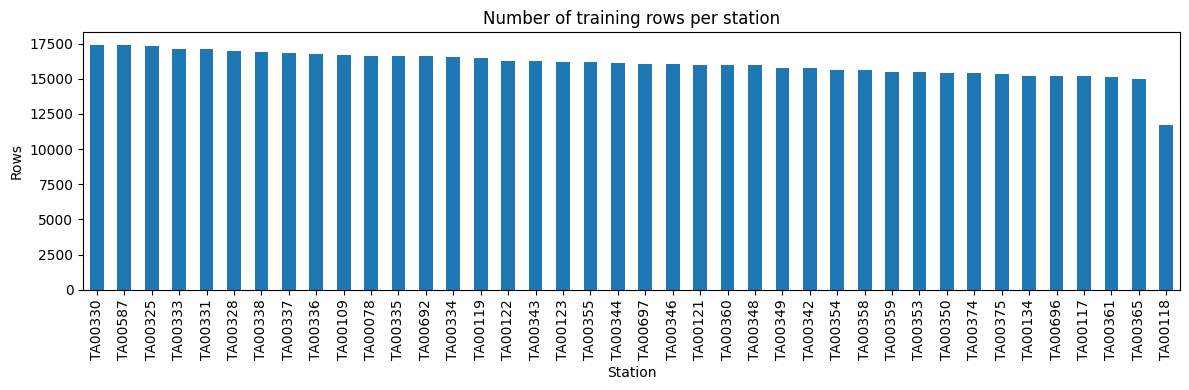

In [ ]:
station_counts = train[station_col].value_counts().sort_values(ascending=False)

plt.figure(figsize=(12, 4))
station_counts.plot(kind="bar")
plt.title("Number of training rows per station")
plt.xlabel("Station")
plt.ylabel("Rows")
plt.tight_layout()
plt.show()


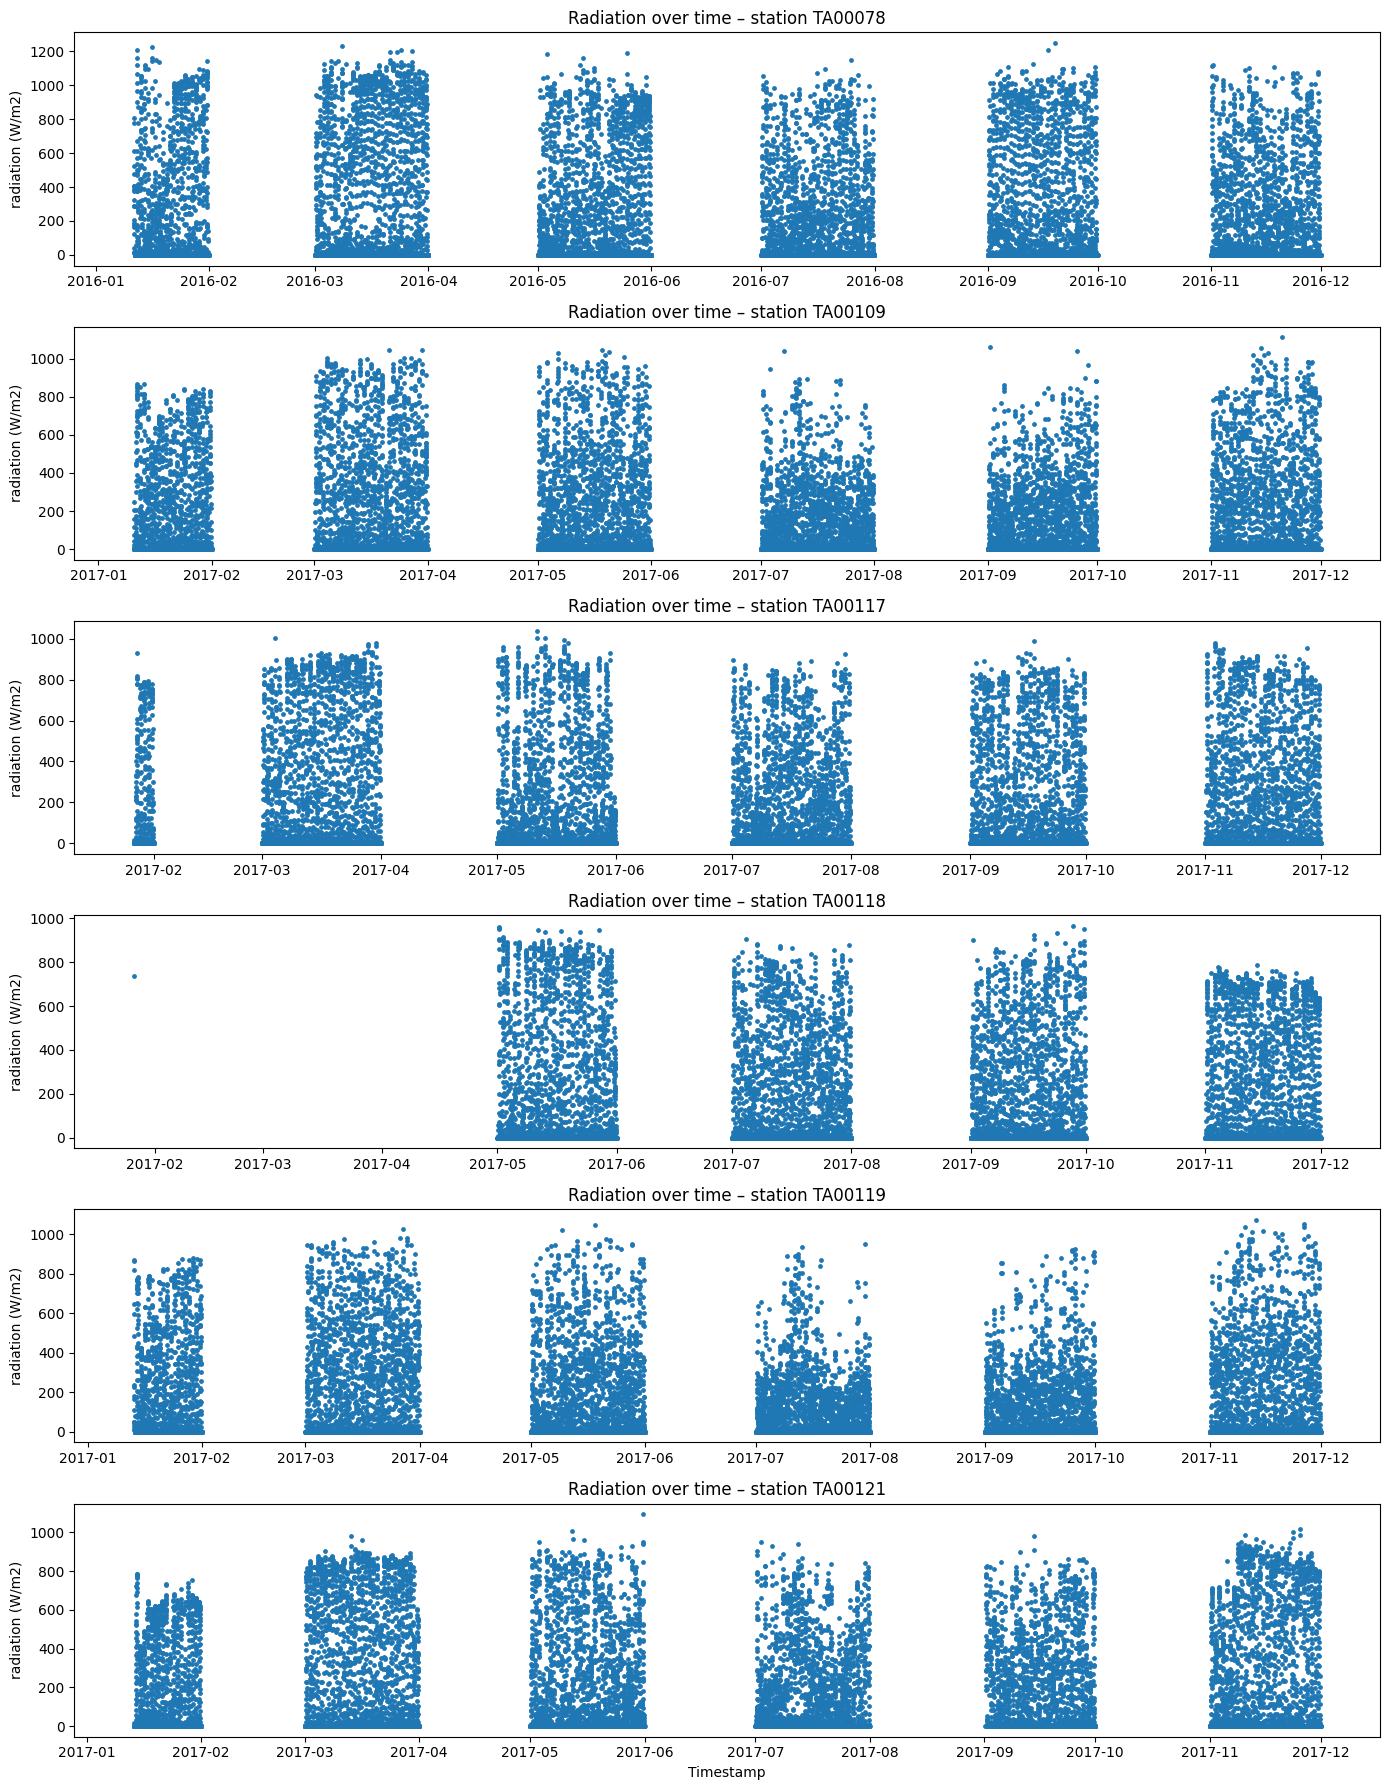

In [ ]:
example_stations = train[station_col].dropna().unique()[:6]

fig, axes = plt.subplots(len(example_stations), 1, figsize=(14, 3 * len(example_stations)), sharex=False)
if len(example_stations) == 1:
    axes = [axes]

for ax, station_value in zip(axes, example_stations):
    g = train.loc[train[station_col] == station_value, [timestamp_col, target_col]].sort_values(timestamp_col)
    ax.scatter(g[timestamp_col], g[target_col], s=6)
    ax.set_title(f"Radiation over time – station {station_value}")
    ax.set_ylabel(target_col)

axes[-1].set_xlabel("Timestamp")
plt.tight_layout()
plt.show()


## ⚙️ Feature engineering

We add a small set of baseline time features:
- month, day, hour, minute
- day of week
- day of year
- cyclical encodings for hour and month

These are simple but useful for solar radiation modelling.


In [ ]:
def add_time_features(df, timestamp_column):
    df = df.copy()
    ts = pd.to_datetime(df[timestamp_column], errors="coerce")

    df["year"] = ts.dt.year
    df["month"] = ts.dt.month
    df["day"] = ts.dt.day
    df["hour"] = ts.dt.hour
    df["minute"] = ts.dt.minute
    df["day_of_week"] = ts.dt.dayofweek
    df["day_of_year"] = ts.dt.dayofyear
    df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

    # Cyclical encodings
    df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
    df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)
    df["doy_sin"] = np.sin(2 * np.pi * df["day_of_year"] / 365.25)
    df["doy_cos"] = np.cos(2 * np.pi * df["day_of_year"] / 365.25)

    return df

train_fe = add_time_features(train, timestamp_col)
test_fe = add_time_features(test, timestamp_col)

display(train_fe.head())


,ID,timestamp,precipitation (mm),radiation (W/m2),relativehumidity (-),temperature (degrees Celsius),station,station_name,country,installation_height,elevation,latitude,longitude,year,month,day,hour,minute,day_of_week,day_of_year,is_weekend,hour_sin,hour_cos,month_sin,month_cos,doy_sin,doy_cos
0,b90ca874_2016-01_D3J06S,2016-01-11 10:30:00,0.0,806.0,0.58,20.4,TA00078,Nyandarua High School,KE,2.5,2427.2,-0.200178,36.376936,2016,1,11,10,30,0,11,0,0.500000,-0.866025,0.5,0.866025,0.188099,0.98215
1,b90ca874_2016-01_CICFMD,2016-01-11 10:45:00,0.0,612.0,0.58,20.5,TA00078,Nyandarua High School,KE,2.5,2427.2,-0.200178,36.376936,2016,1,11,10,45,0,11,0,0.500000,-0.866025,0.5,0.866025,0.188099,0.98215
2,b90ca874_2016-01_7YYUCC,2016-01-11 11:00:00,0.0,775.0,0.55,20.4,TA00078,Nyandarua High School,KE,2.5,2427.2,-0.200178,36.376936,2016,1,11,11,0,0,11,0,0.258819,-0.965926,0.5,0.866025,0.188099,0.98215
3,b90ca874_2016-01_GC3UW6,2016-01-11 11:15:00,0.0,379.0,0.56,20.5,TA00078,Nyandarua High School,KE,2.5,2427.2,-0.200178,36.376936,2016,1,11,11,15,0,11,0,0.258819,-0.965926,0.5,0.866025,0.188099,0.98215
4,b90ca874_2016-01_DJLS3P,2016-01-11 11:30:00,0.0,405.0,0.58,19.7,TA00078,Nyandarua High School,KE,2.5,2427.2,-0.200178,36.376936,2016,1,11,11,30,0,11,0,0.258819,-0.965926,0.5,0.866025,0.188099,0.98215


## 🧱 Select modelling features

Because we train **one model per station**, we do **not** use the station identifier itself as a feature.  
We keep numeric weather and time variables and exclude IDs, timestamps, and the target.


In [ ]:
exclude_cols = {
    id_col,
    station_col,
    timestamp_col,
    target_col,
}

numeric_feature_cols = [
    col for col in train_fe.select_dtypes(include=[np.number]).columns
    if col not in exclude_cols
]

print("Number of numeric feature columns:", len(numeric_feature_cols))
print(numeric_feature_cols)


Number of numeric feature columns: 21
['precipitation (mm)', 'relativehumidity (-)', 'temperature (degrees Celsius)', 'installation_height', 'elevation', 'latitude', 'longitude', 'year', 'month', 'day', 'hour', 'minute', 'day_of_week', 'day_of_year', 'is_weekend', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'doy_sin', 'doy_cos']


## 🤖 Define the baseline model

This baseline uses a `RandomForestRegressor` inside a small pipeline:
- median imputation for missing values
- optional scaling step for consistency
- random forest regression

You can replace this with XGBoost, LightGBM, CatBoost, ExtraTrees, or any stronger model later.


In [ ]:
base_model = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", RandomForestRegressor(
            n_estimators=300,
            max_depth=10,
            min_samples_leaf=5,
            random_state=42,
            n_jobs=-1,
        )),
    ]
)

base_model


Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('model',
                 RandomForestRegressor(max_depth=10, min_samples_leaf=5,
                                       n_estimators=300, n_jobs=-1,
                                       random_state=42))])

## 🏗️ Train one model per station and predict the test set

The train and test data include many stations in the same file.  
This block loops over stations, fits a separate model for each one, and predicts only that station’s test rows.

If a station appears in the test set but not the training set, the notebook falls back to a global model trained on all stations.


In [ ]:
# Global fallback model
global_model = clone(base_model)
global_model.fit(train_fe[numeric_feature_cols], train_fe[target_col])

station_models = {}
station_predictions = []

test_stations = test_fe[station_col].dropna().unique()

for station_value in test_stations:
    train_station = train_fe[train_fe[station_col] == station_value].copy()
    test_station = test_fe[test_fe[station_col] == station_value].copy()

    if len(test_station) == 0:
        continue

    if len(train_station) < 20:
        model = global_model
        model_name = "global_fallback"
    else:
        model = clone(base_model)
        model.fit(train_station[numeric_feature_cols], train_station[target_col])
        station_models[station_value] = model
        model_name = "station_model"

    preds = model.predict(test_station[numeric_feature_cols])

    station_pred_df = pd.DataFrame({
        id_col: test_station[id_col].values,
        "prediction": preds,
        "station_used": station_value,
        "model_type": model_name,
    })
    station_predictions.append(station_pred_df)

pred_df = pd.concat(station_predictions, axis=0, ignore_index=True)
pred_df.head()


,ID,prediction,station_used,model_type
0,b90ca874_2016-02_R0DXEB,0.0,TA00078,station_model
1,b90ca874_2016-02_NC9LCK,0.0,TA00078,station_model
2,b90ca874_2016-02_1H20M4,0.0,TA00078,station_model
3,b90ca874_2016-02_5J12GN,0.0,TA00078,station_model
4,b90ca874_2016-02_3AJGWD,0.0,TA00078,station_model


In [ ]:
print("Number of station-specific models trained:", len(station_models))
print("Predictions created:", pred_df.shape[0])
print("Unique stations predicted:", pred_df["station_used"].nunique())


Number of station-specific models trained: 40
Predictions created: 683353
Unique stations predicted: 40


## 📝 Build the submission file

For this challenge, the same radiation prediction is written to both submission columns:
- `TargetMBE`
- `TargetRMSE`

That is because the leaderboard metric computes MBE and RMSE from the submitted predicted radiation values against the hidden observed radiation values.


In [ ]:
submission = sample_submission.copy()

submission = submission.merge(
    pred_df[[id_col, "prediction"]],
    on=id_col,
    how="left"
)

submission["TargetMBE"] = submission["prediction"]
submission["TargetRMSE"] = submission["prediction"]

submission = submission.drop(columns=["prediction"])

submission.head()


,ID,TargetMBE,TargetRMSE
0,f9f1b75a_2018-02_XPH0JM,0.0,0.0
1,f9f1b75a_2018-02_AQHEJH,0.0,0.0
2,f9f1b75a_2018-02_8FNJMM,0.0,0.0
3,f9f1b75a_2018-02_THO15Y,0.0,0.0
4,f9f1b75a_2018-02_8IY2KA,0.0,0.0


In [ ]:
print("Missing predictions in submission:", submission[["TargetMBE", "TargetRMSE"]].isnull().sum().sum())
print("Submission shape:", submission.shape)


Missing predictions in submission: 0
Submission shape: (683353, 3)


In [ ]:
submission.to_csv("tahmo_starter_submission_per_station.csv", index=False)
print("Saved: tahmo_starter_submission_per_station.csv")


Saved: tahmo_starter_submission_per_station.csv


## ✅ What to try next

This is only a baseline. Strong improvements may come from:
- better station-specific validation
- lags and rolling weather features
- sunrise/sunset and solar geometry features
- external EO data such as LANDSAF or TROPOMI
- stronger models and tuned hyperparameters
- blending models across stations

Good luck, and happy modelling!
